In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [286]:
df =pd.read_csv(r"D:\data\Fraud_Analysis_Dataset.csv",)
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0


In [287]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [288]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

In [289]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [290]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])


In [291]:
df.dtypes

step                int64
type                int64
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

In [292]:
df['newbalanceOrig'].value_counts().sum()

np.int64(11142)

In [293]:
df[df['isFraud']==1].value_counts().sum()

np.int64(1142)

In [294]:
df.shape[0]


11142

In [295]:
df.duplicated().sum()

np.int64(0)

In [296]:
round(df['isFraud'].value_counts()[1] /df['isFraud'].value_counts()[0] *100,2)

np.float64(11.42)

In [297]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df['type']

0        4
1        1
2        4
3        1
4        4
        ..
11137    2
11138    1
11139    1
11140    3
11141    3
Name: type, Length: 11142, dtype: int64

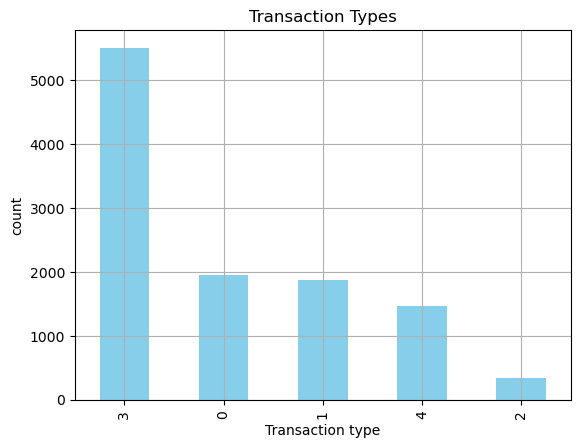

In [298]:
df["type"].value_counts().plot(kind='bar',title ="Transaction Types" , color ='skyblue')
plt.xlabel("Transaction type")
plt.ylabel("count")
plt.grid()
plt.show()

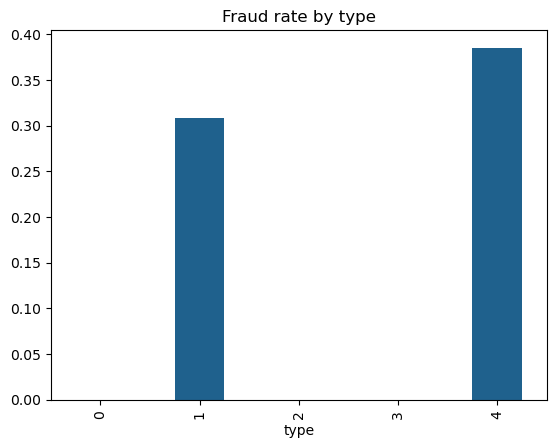

In [299]:
fraud_by_type = df.groupby("type")["isFraud"].mean()
fraud_by_type.plot(kind='bar',title ='Fraud rate by type',color = '#1F618D')
plt.show()

In [300]:
df['amount_category'] = pd.cut(
    df['amount'],
    bins=[0, 50000, 100000, df['amount'].max()],
    labels=['Normal', 'High', 'Very High']
)


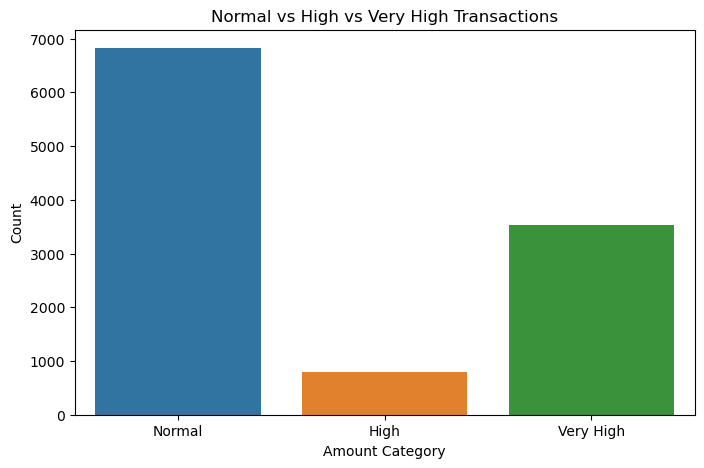

In [301]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='amount_category',hue='amount_category')
plt.title("Normal vs High vs Very High Transactions")
plt.xlabel("Amount Category")
plt.ylabel("Count")
plt.show()


In [302]:
df['amount'].describe().astype(int)

count       11142
mean       213191
std        760065
min             2
25%          4946
50%         16761
75%        154336
max      10000000
Name: amount, dtype: int64

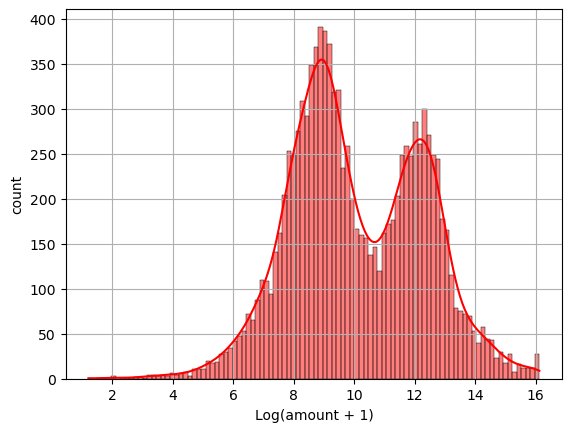

In [303]:
 sns.histplot(np.log1p(df['amount']),bins = 100 , color='red',kde=True)
plt.xlabel('Log(amount + 1)')
plt.ylabel('count')
plt.grid()
plt.show()

In [304]:
import pandas as pd

# Assuming your dataframe is df
skewness = df['amount'].skew()
print("Skewness of amount column:", skewness)


Skewness of amount column: 8.392240800807095


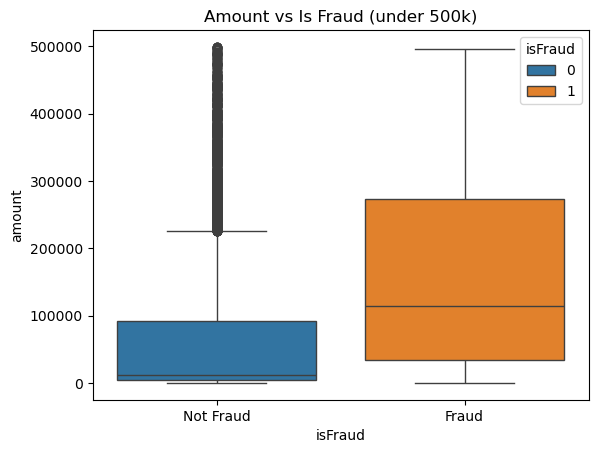

In [305]:
sns.boxplot(data=df[df['amount'] < 500000], x='isFraud', y='amount',hue='isFraud')
plt.title("Amount vs Is Fraud (under 500k)")
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.show()


In [306]:
df['amount_log'] = np.log1p(df['amount'])
df['amount_log']

0         5.204007
1         5.204007
2         7.939872
3         7.939872
4         9.909917
           ...    
11137     8.763226
11138    12.607532
11139    12.955507
11140     6.998537
11141     9.130927
Name: amount_log, Length: 11142, dtype: float64

In [307]:
import numpy as np

df['log_oldbalanceOrg']  = np.log1p(df['oldbalanceOrg'])
df['log_newbalanceOrig'] = np.log1p(df['newbalanceOrig'])
df['log_oldbalanceDest'] = np.log1p(df['oldbalanceDest'])
df['log_newbalanceDest'] = np.log1p(df['newbalanceDest'])


In [308]:
df.dtypes

step                     int64
type                     int64
amount                 float64
nameOrig                object
oldbalanceOrg          float64
newbalanceOrig         float64
nameDest                object
oldbalanceDest         float64
newbalanceDest         float64
isFraud                  int64
amount_category       category
amount_log             float64
log_oldbalanceOrg      float64
log_newbalanceOrig     float64
log_oldbalanceDest     float64
log_newbalanceDest     float64
dtype: object

In [309]:
df['high_amount'] = (df['amount'] > 100000).astype(int)
df['very_high_amount'] = (df['amount'] > 250000).astype(int)
df['very_high_amount']

0        0
1        0
2        0
3        0
4        0
        ..
11137    0
11138    1
11139    1
11140    0
11141    0
Name: very_high_amount, Length: 11142, dtype: int64

In [310]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,amount_category,amount_log,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest,high_amount,very_high_amount
0,1,4,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,Normal,5.204007,5.204007,0.000000,0.000000,0.000000,0,0
1,1,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,Normal,5.204007,5.204007,0.000000,9.960954,0.000000,0,0
2,1,4,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,Normal,7.939872,7.939872,0.000000,0.000000,0.000000,0,0
3,1,1,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,Normal,7.939872,7.939872,0.000000,10.173629,0.000000,0,0
4,1,4,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,Normal,9.909917,9.909917,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,2,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,Normal,8.763226,12.978690,12.963817,13.078248,12.257413,0,0
11138,7,1,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,Very High,12.607532,12.963817,11.758943,13.465040,15.477610,1,1
11139,7,1,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,Very High,12.955507,11.758943,0.000000,13.322001,13.527325,1,1
11140,7,3,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,Normal,6.998537,9.541010,9.459149,0.000000,0.000000,0,0


In [311]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,amount_category,amount_log,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest,high_amount,very_high_amount
0,1,4,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,Normal,5.204007,5.204007,0.000000,0.000000,0.000000,0,0
1,1,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,Normal,5.204007,5.204007,0.000000,9.960954,0.000000,0,0
2,1,4,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,Normal,7.939872,7.939872,0.000000,0.000000,0.000000,0,0
3,1,1,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,Normal,7.939872,7.939872,0.000000,10.173629,0.000000,0,0
4,1,4,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,Normal,9.909917,9.909917,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,2,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,Normal,8.763226,12.978690,12.963817,13.078248,12.257413,0,0
11138,7,1,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,Very High,12.607532,12.963817,11.758943,13.465040,15.477610,1,1
11139,7,1,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,Very High,12.955507,11.758943,0.000000,13.322001,13.527325,1,1
11140,7,3,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,Normal,6.998537,9.541010,9.459149,0.000000,0.000000,0,0


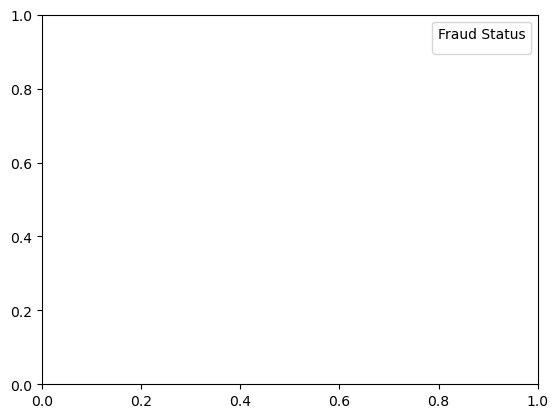

In [312]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
ax = sns.countplot(data=fraud_types, x='type', hue='isFraud')
ax.legend(title="Fraud Status", labels=["Non-Fraud", "Fraud"])



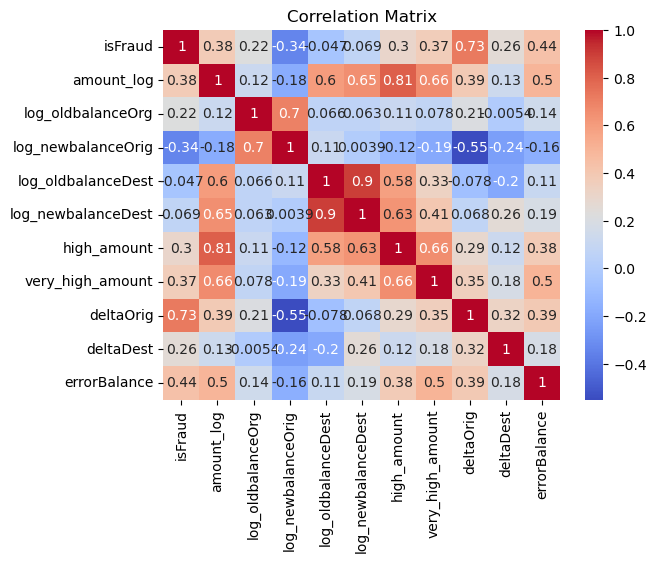

In [313]:
sns.heatmap(corr,annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

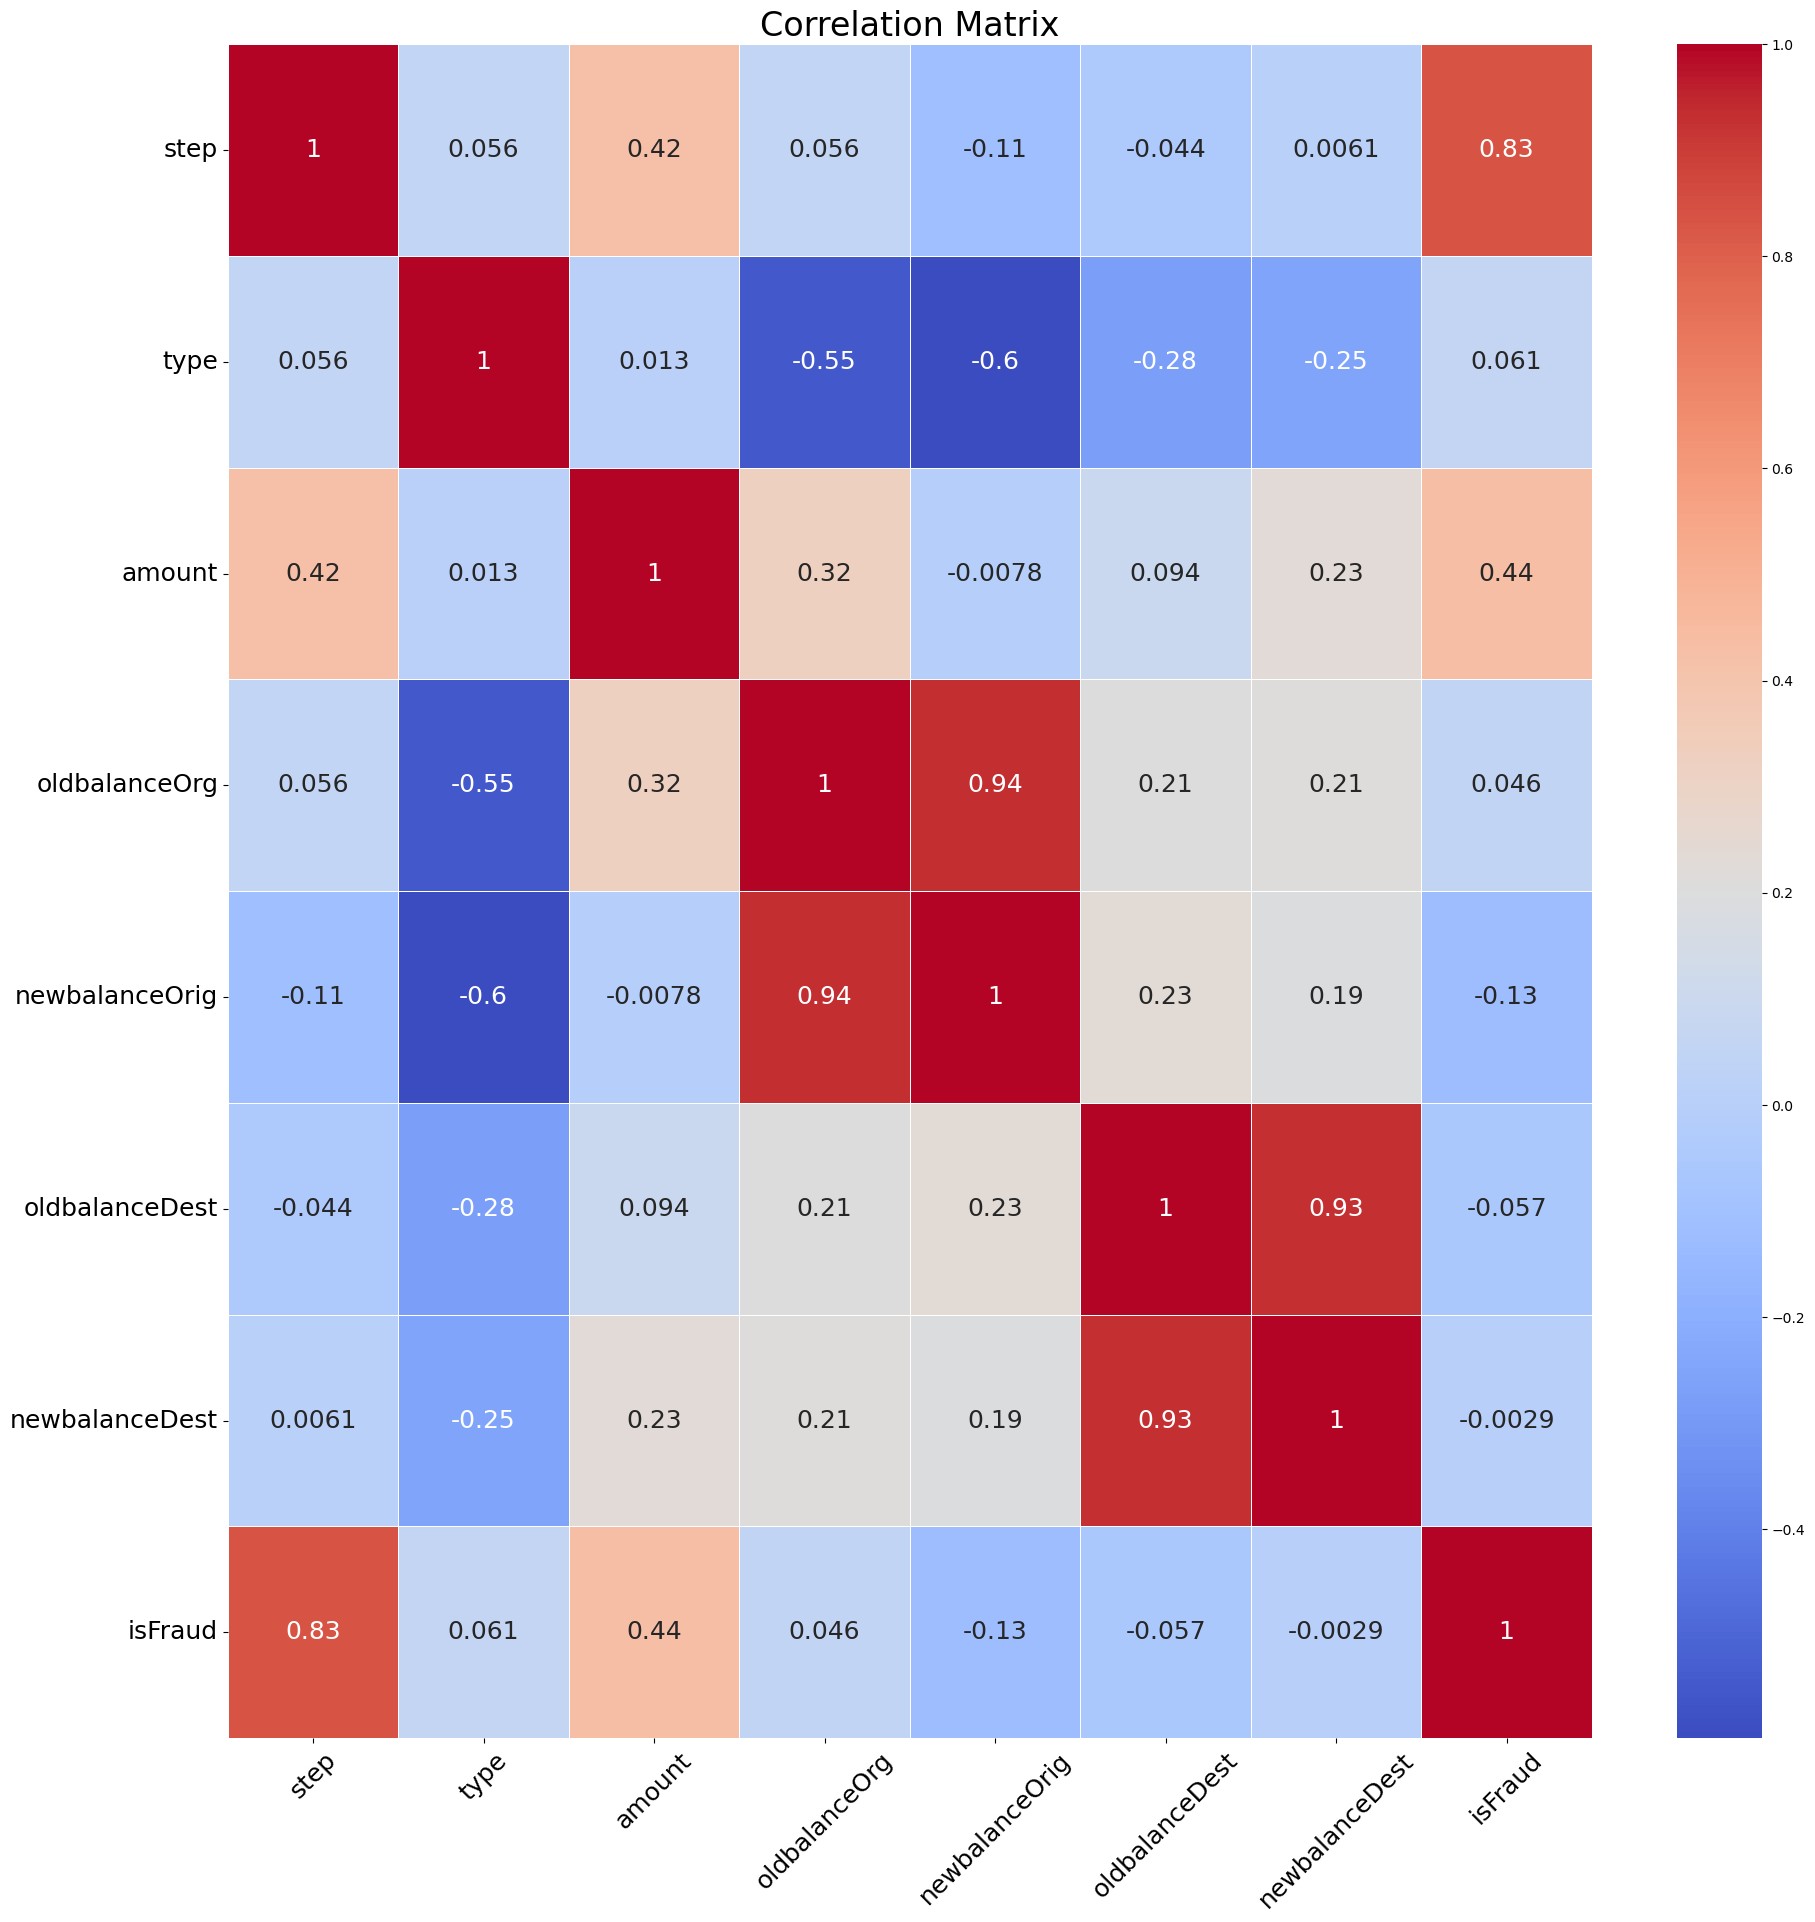

In [314]:
plt.figure(figsize=(22, 22))

sns.heatmap(
    corr0,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 18},  # Increase number labels inside cells
    linewidths=0.5
)

plt.title('Correlation Matrix', fontsize=24)  # Increase title size

plt.xticks(fontsize=18, rotation=45)  # Increase x-axis label size
plt.yticks(fontsize=18, rotation=0)   # Increase y-axis label size

plt.show()


In [315]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,amount_category,amount_log,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest,high_amount,very_high_amount
0,1,4,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,Normal,5.204007,5.204007,0.000000,0.000000,0.000000,0,0
1,1,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,Normal,5.204007,5.204007,0.000000,9.960954,0.000000,0,0
2,1,4,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,Normal,7.939872,7.939872,0.000000,0.000000,0.000000,0,0
3,1,1,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,Normal,7.939872,7.939872,0.000000,10.173629,0.000000,0,0
4,1,4,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,Normal,9.909917,9.909917,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,2,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,Normal,8.763226,12.978690,12.963817,13.078248,12.257413,0,0
11138,7,1,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,Very High,12.607532,12.963817,11.758943,13.465040,15.477610,1,1
11139,7,1,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,Very High,12.955507,11.758943,0.000000,13.322001,13.527325,1,1
11140,7,3,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,Normal,6.998537,9.541010,9.459149,0.000000,0.000000,0,0


In [316]:
df['deltaOrig'] = df['log_oldbalanceOrg'] - df['log_newbalanceOrig']

In [317]:
df['deltaDest'] = df['log_newbalanceDest'] - df['log_oldbalanceDest'] 

In [318]:
df['errorBalance'] = df['amount'] - df['deltaOrig'] 

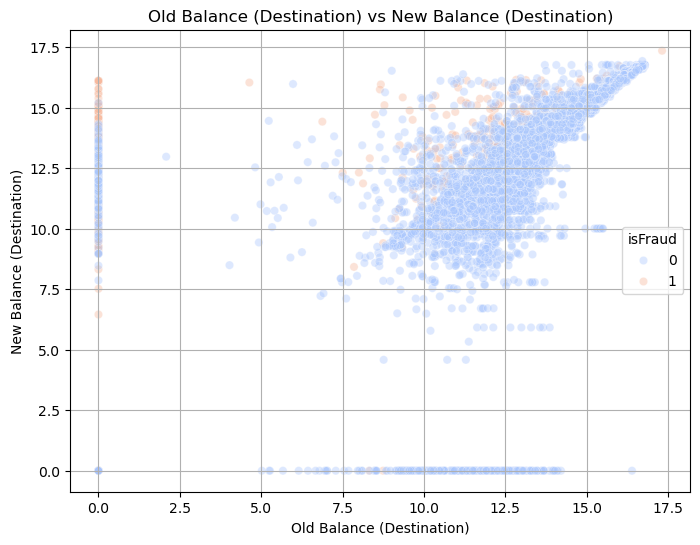

In [319]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='log_oldbalanceDest',
    y='log_newbalanceDest',
    hue='isFraud',
    alpha=0.4,
    palette='coolwarm'
)
plt.title("Old Balance (Destination) vs New Balance (Destination)")
plt.xlabel("Old Balance (Destination)")
plt.ylabel("New Balance (Destination)")
plt.grid(True)
plt.show()


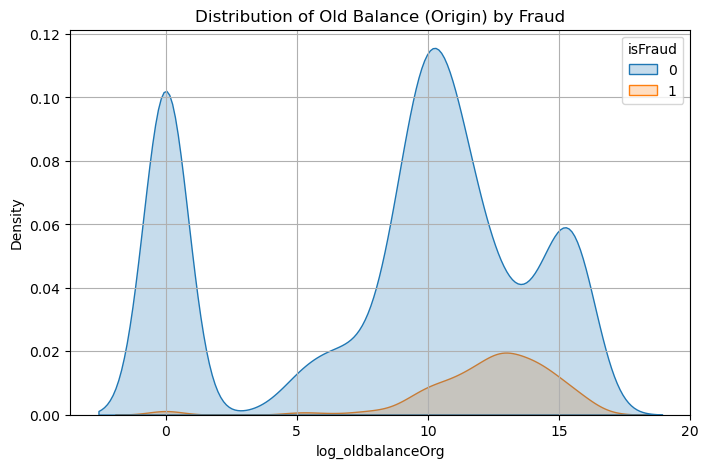

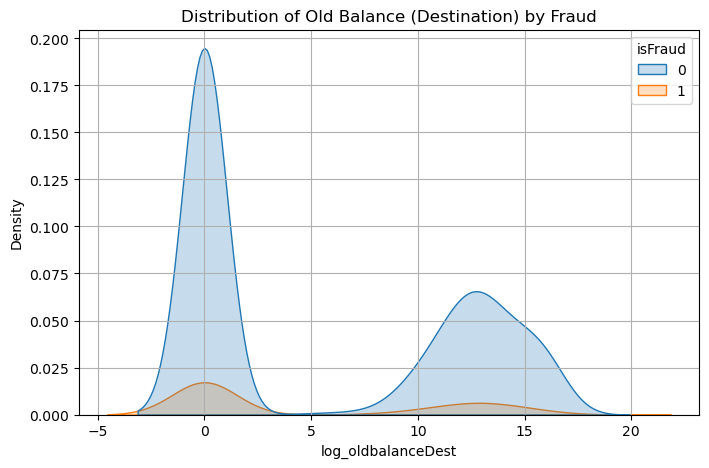

In [320]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_oldbalanceOrg', hue='isFraud', fill=True)
plt.title("Distribution of Old Balance (Origin) by Fraud")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_oldbalanceDest', hue='isFraud', fill=True)
plt.title("Distribution of Old Balance (Destination) by Fraud")
plt.grid(True)
plt.show()


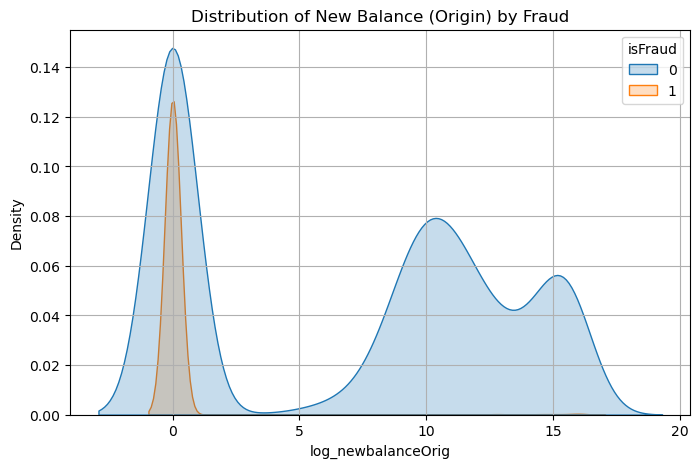

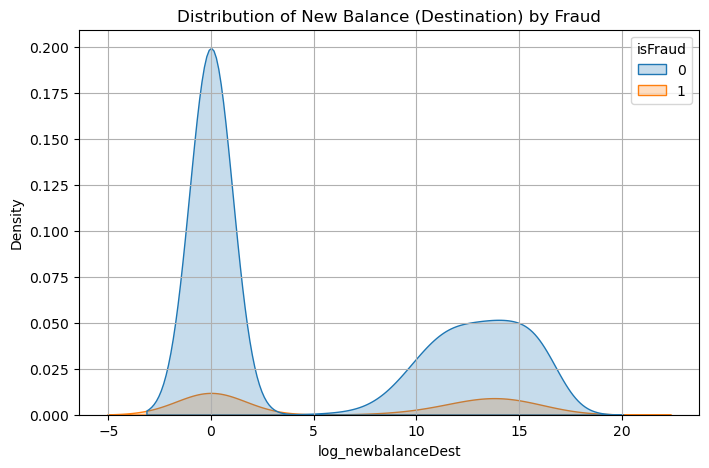

In [321]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_newbalanceOrig', hue='isFraud', fill=True)
plt.title("Distribution of New Balance (Origin) by Fraud")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_newbalanceDest', hue='isFraud', fill=True)
plt.title("Distribution of New Balance (Destination) by Fraud")
plt.grid(True)
plt.show()


In [322]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [323]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'amount_category', 'amount_log', 'log_oldbalanceOrg',
       'log_newbalanceOrig', 'log_oldbalanceDest', 'log_newbalanceDest',
       'high_amount', 'very_high_amount', 'deltaOrig', 'deltaDest',
       'errorBalance'],
      dtype='object')

In [324]:
df_model = df.drop(['amount','amount_category','step','type','nameOrig','nameDest','oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest','log_oldbalanceDest','log_newbalanceDest','log_oldbalanceOrg','high_amount','very_high_amount'],axis=1)
df_model

,isFraud,amount_log,log_newbalanceOrig,deltaOrig,deltaDest,errorBalance
0,1,5.204007,0.000000,5.204007,0.000000,175.795993
1,1,5.204007,0.000000,5.204007,-9.960954,175.795993
2,1,7.939872,0.000000,7.939872,0.000000,2798.060128
3,1,7.939872,0.000000,7.939872,-10.173629,2798.060128
4,1,9.909917,0.000000,9.909917,0.000000,20118.090083
...,...,...,...,...,...,...
11137,0,8.763226,12.963817,0.014873,-0.820835,6393.695127
11138,0,12.607532,11.758943,1.204874,2.012571,298798.335126
11139,0,12.955507,0.000000,11.758943,0.205324,423147.871057
11140,0,6.998537,9.459149,0.081861,0.000000,1093.948139


In [325]:
df_model.describe()

,isFraud,amount_log,log_newbalanceOrig,deltaOrig,deltaDest,errorBalance
count,11142.000000,11142.000000,11142.000000,11142.000000,11142.000000,1.114200e+04
mean,0.102495,10.096826,6.365867,2.510997,0.081188,2.131890e+05
std,0.303312,2.201797,6.219916,4.528963,2.995094,7.600632e+05
min,0.000000,1.220830,0.000000,-12.845021,-16.388123,2.389942e+00
25%,0.000000,8.506661,0.000000,0.000000,0.000000,4.946612e+03
50%,0.000000,9.726885,8.394258,0.046369,0.000000,1.675989e+04
75%,0.000000,11.946897,11.621004,2.500937,0.009747,1.543366e+05
max,1.000000,16.118096,16.380460,16.118096,16.118096,9.999999e+06


In [326]:
X= df_model.drop('isFraud',axis=1)
y=df_model['isFraud']

In [327]:
# TRAIN TEST SPLITN 

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state =42,test_size=0.3,stratify = y)

In [328]:
num_cols = df_model.select_dtypes(include=['number']).columns
print(num_cols)

Index(['isFraud', 'amount_log', 'log_newbalanceOrig', 'deltaOrig', 'deltaDest',
       'errorBalance'],
      dtype='object')


In [329]:
corr1 = df_model.corr()
corr1

,isFraud,amount_log,log_newbalanceOrig,deltaOrig,deltaDest,errorBalance
isFraud,1.000000,0.380348,-0.339590,0.725906,0.257185,0.435487
amount_log,0.380348,1.000000,-0.177815,0.386389,0.129904,0.496704
log_newbalanceOrig,-0.339590,-0.177815,1.000000,-0.550580,-0.238803,-0.163821
deltaOrig,0.725906,0.386389,-0.550580,1.000000,0.321641,0.392509
deltaDest,0.257185,0.129904,-0.238803,0.321641,1.000000,0.177045
errorBalance,0.435487,0.496704,-0.163821,0.392509,0.177045,1.000000


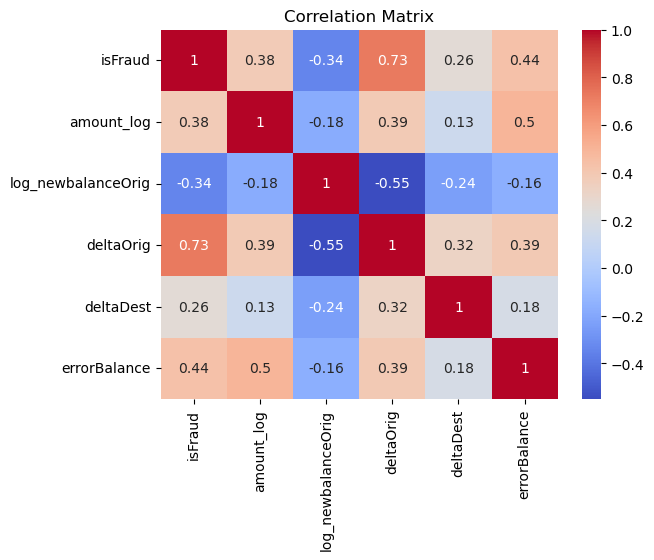

In [330]:
sns.heatmap(corr1,annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## xgb_model

In [331]:
df_model.dtypes

isFraud                 int64
amount_log            float64
log_newbalanceOrig    float64
deltaOrig             float64
deltaDest             float64
errorBalance          float64
dtype: object

In [332]:
df_model.columns

Index(['isFraud', 'amount_log', 'log_newbalanceOrig', 'deltaOrig', 'deltaDest',
       'errorBalance'],
      dtype='object')

In [333]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))


C:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:52:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[2988   12]
 [  18  325]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3000
           1       0.96      0.95      0.96       343

    accuracy                           0.99      3343
   macro avg       0.98      0.97      0.98      3343
weighted avg       0.99      0.99      0.99      3343

ROC-AUC Score: 0.9973153547133139


In [334]:
df_model.columns

Index(['isFraud', 'amount_log', 'log_newbalanceOrig', 'deltaOrig', 'deltaDest',
       'errorBalance'],
      dtype='object')

## Random  Forest

In [335]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [358]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
rf.fit(X_train, y_train)

# Predict
y_pred1 = rf.predict(X_test)

# Evaluate

print("Cross-validation AUC scores:", scores)
print("Mean AUC:", np.mean(scores))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred1))


Cross-validation AUC scores: [0.99107589 0.99502455 0.99067188 0.99532813 0.99562893]
Mean AUC: 0.9935458754492362
Confusion Matrix:
 [[2989   11]
 [  20  323]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3000
           1       0.97      0.94      0.95       343

    accuracy                           0.99      3343
   macro avg       0.98      0.97      0.97      3343
weighted avg       0.99      0.99      0.99      3343

ROC-AUC Score: 0.9690121477162293


In [337]:
X_train.columns

Index(['amount_log', 'log_newbalanceOrig', 'deltaOrig', 'deltaDest',
       'errorBalance'],
      dtype='object')

In [338]:
importances = rf.feature_importances_
features = X_train.columns

# Create a DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp)

              Feature  Importance
2           deltaOrig    0.642378
0          amount_log    0.137789
4        errorBalance    0.132261
3           deltaDest    0.060164
1  log_newbalanceOrig    0.027408


# LGB

In [339]:
!pip install lightgbm
import lightgbm as lgb

In [340]:
from lightgbm import LGBMClassifier, LGBMRegressor


In [341]:
weight = y_train.value_counts()[0] / y_train.value_counts()[1]
weight


np.float64(8.760951188986233)

In [342]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    scale_pos_weight=weight,   # imbalance handling
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1
)

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 799, number of negative: 7000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 7799, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102449 -> initscore=-2.170304
[LightGBM] [Info] Start training from score -2.170304
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.02, n_estimators=1000,
               reg_lambda=1, scale_pos_weight=np.float64(8.760951188986233),
               subsample=0.7)

In [343]:
y_pred2 = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [344]:
print(confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


[[2985   15]
 [  16  327]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3000
           1       0.96      0.95      0.95       343

    accuracy                           0.99      3343
   macro avg       0.98      0.97      0.97      3343
weighted avg       0.99      0.99      0.99      3343

ROC AUC: 0.997402332361516


In [345]:
from sklearn.model_selection import GridSearchCV

models = {
    "RandomForest": RandomForestClassifier(),
    "LightGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss') #XGBoost requires an evaluation metric,logloss is best for binary classification , Prevents warnings about default metrics
}


param_grid = {

    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, 15],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "LightGBM": {
        "num_leaves": [31, 50],
        "learning_rate": [0.01, 0.05, 0.1],
        "n_estimators": [200, 500],
        "max_depth": [-1, 10, 20]
    },

    "XGBoost": {
        "learning_rate": [0.01, 0.1],
        "n_estimators": [200, 400],
        "max_depth": [3, 6, 10],
        "subsample": [0.7, 1],
        "colsample_bytree": [0.7, 1]
    }
}


best_models = {}

for name in models:
    print(f"\n🔍 Tuning {name}...")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grid[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    print(f"Best Parameters for {name}: {grid.best_params_}")
    print(f"Best ROC-AUC: {grid.best_score_}")


from sklearn.metrics import roc_auc_score

print("\n📊 Test ROC-AUC Scores:")
for name, model in best_models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"{name}: {auc}")



🔍 Tuning RandomForest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for RandomForest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best ROC-AUC: 0.9966507973944294

🔍 Tuning LightGBM...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[LightGBM] [Info] Number of positive: 799, number of negative: 7000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 7799, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102449 -> initscore=-2.170304
[LightGBM] [Info] Start training from score -2.170304
Best Parameters for LightGBM: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
Best ROC-AUC: 0.9964567750449236

🔍 Tuning XGBoost...
Fitting 5 folds for ea

In [346]:
from sklearn.model_selection import GridSearchCV
model ={'Randomforst',RandomForestClassifier(),
       'LightGBM',LGBMClassifier(),
       'XGBoost',XGBClassifier()}

In [347]:
corr = df[['isFraud','amount_log','log_oldbalanceOrg','log_newbalanceOrig','log_oldbalanceDest','log_newbalanceDest','high_amount','very_high_amount','deltaOrig','deltaDest','errorBalance']].corr()
corr

,isFraud,amount_log,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest,high_amount,very_high_amount,deltaOrig,deltaDest,errorBalance
isFraud,1.000000,0.380348,0.221418,-0.339590,-0.047211,0.069332,0.300232,0.367034,0.725906,0.257185,0.435487
amount_log,0.380348,1.000000,0.121306,-0.177815,0.600864,0.650351,0.807164,0.663565,0.386389,0.129904,0.496704
log_oldbalanceOrg,0.221418,0.121306,1.000000,0.701970,0.066190,0.062767,0.110175,0.078296,0.208047,-0.005394,0.142925
log_newbalanceOrig,-0.339590,-0.177815,0.701970,1.000000,0.113113,0.003860,-0.117926,-0.190192,-0.550580,-0.238803,-0.163821
log_oldbalanceDest,-0.047211,0.600864,0.066190,0.113113,1.000000,0.897142,0.584621,0.329018,-0.077764,-0.195039,0.109464
log_newbalanceDest,0.069332,0.650351,0.062767,0.003860,0.897142,1.000000,0.631554,0.405996,0.068268,0.258281,0.187560
high_amount,0.300232,0.807164,0.110175,-0.117926,0.584621,0.631554,1.000000,0.660081,0.291091,0.123693,0.380106
very_high_amount,0.367034,0.663565,0.078296,-0.190192,0.329018,0.405996,0.660081,1.000000,0.352975,0.181880,0.497729
deltaOrig,0.725906,0.386389,0.208047,-0.550580,-0.077764,0.068268,0.291091,0.352975,1.000000,0.321641,0.392509
deltaDest,0.257185,0.129904,-0.005394,-0.238803,-0.195039,0.258281,0.123693,0.181880,0.321641,1.000000,0.177045


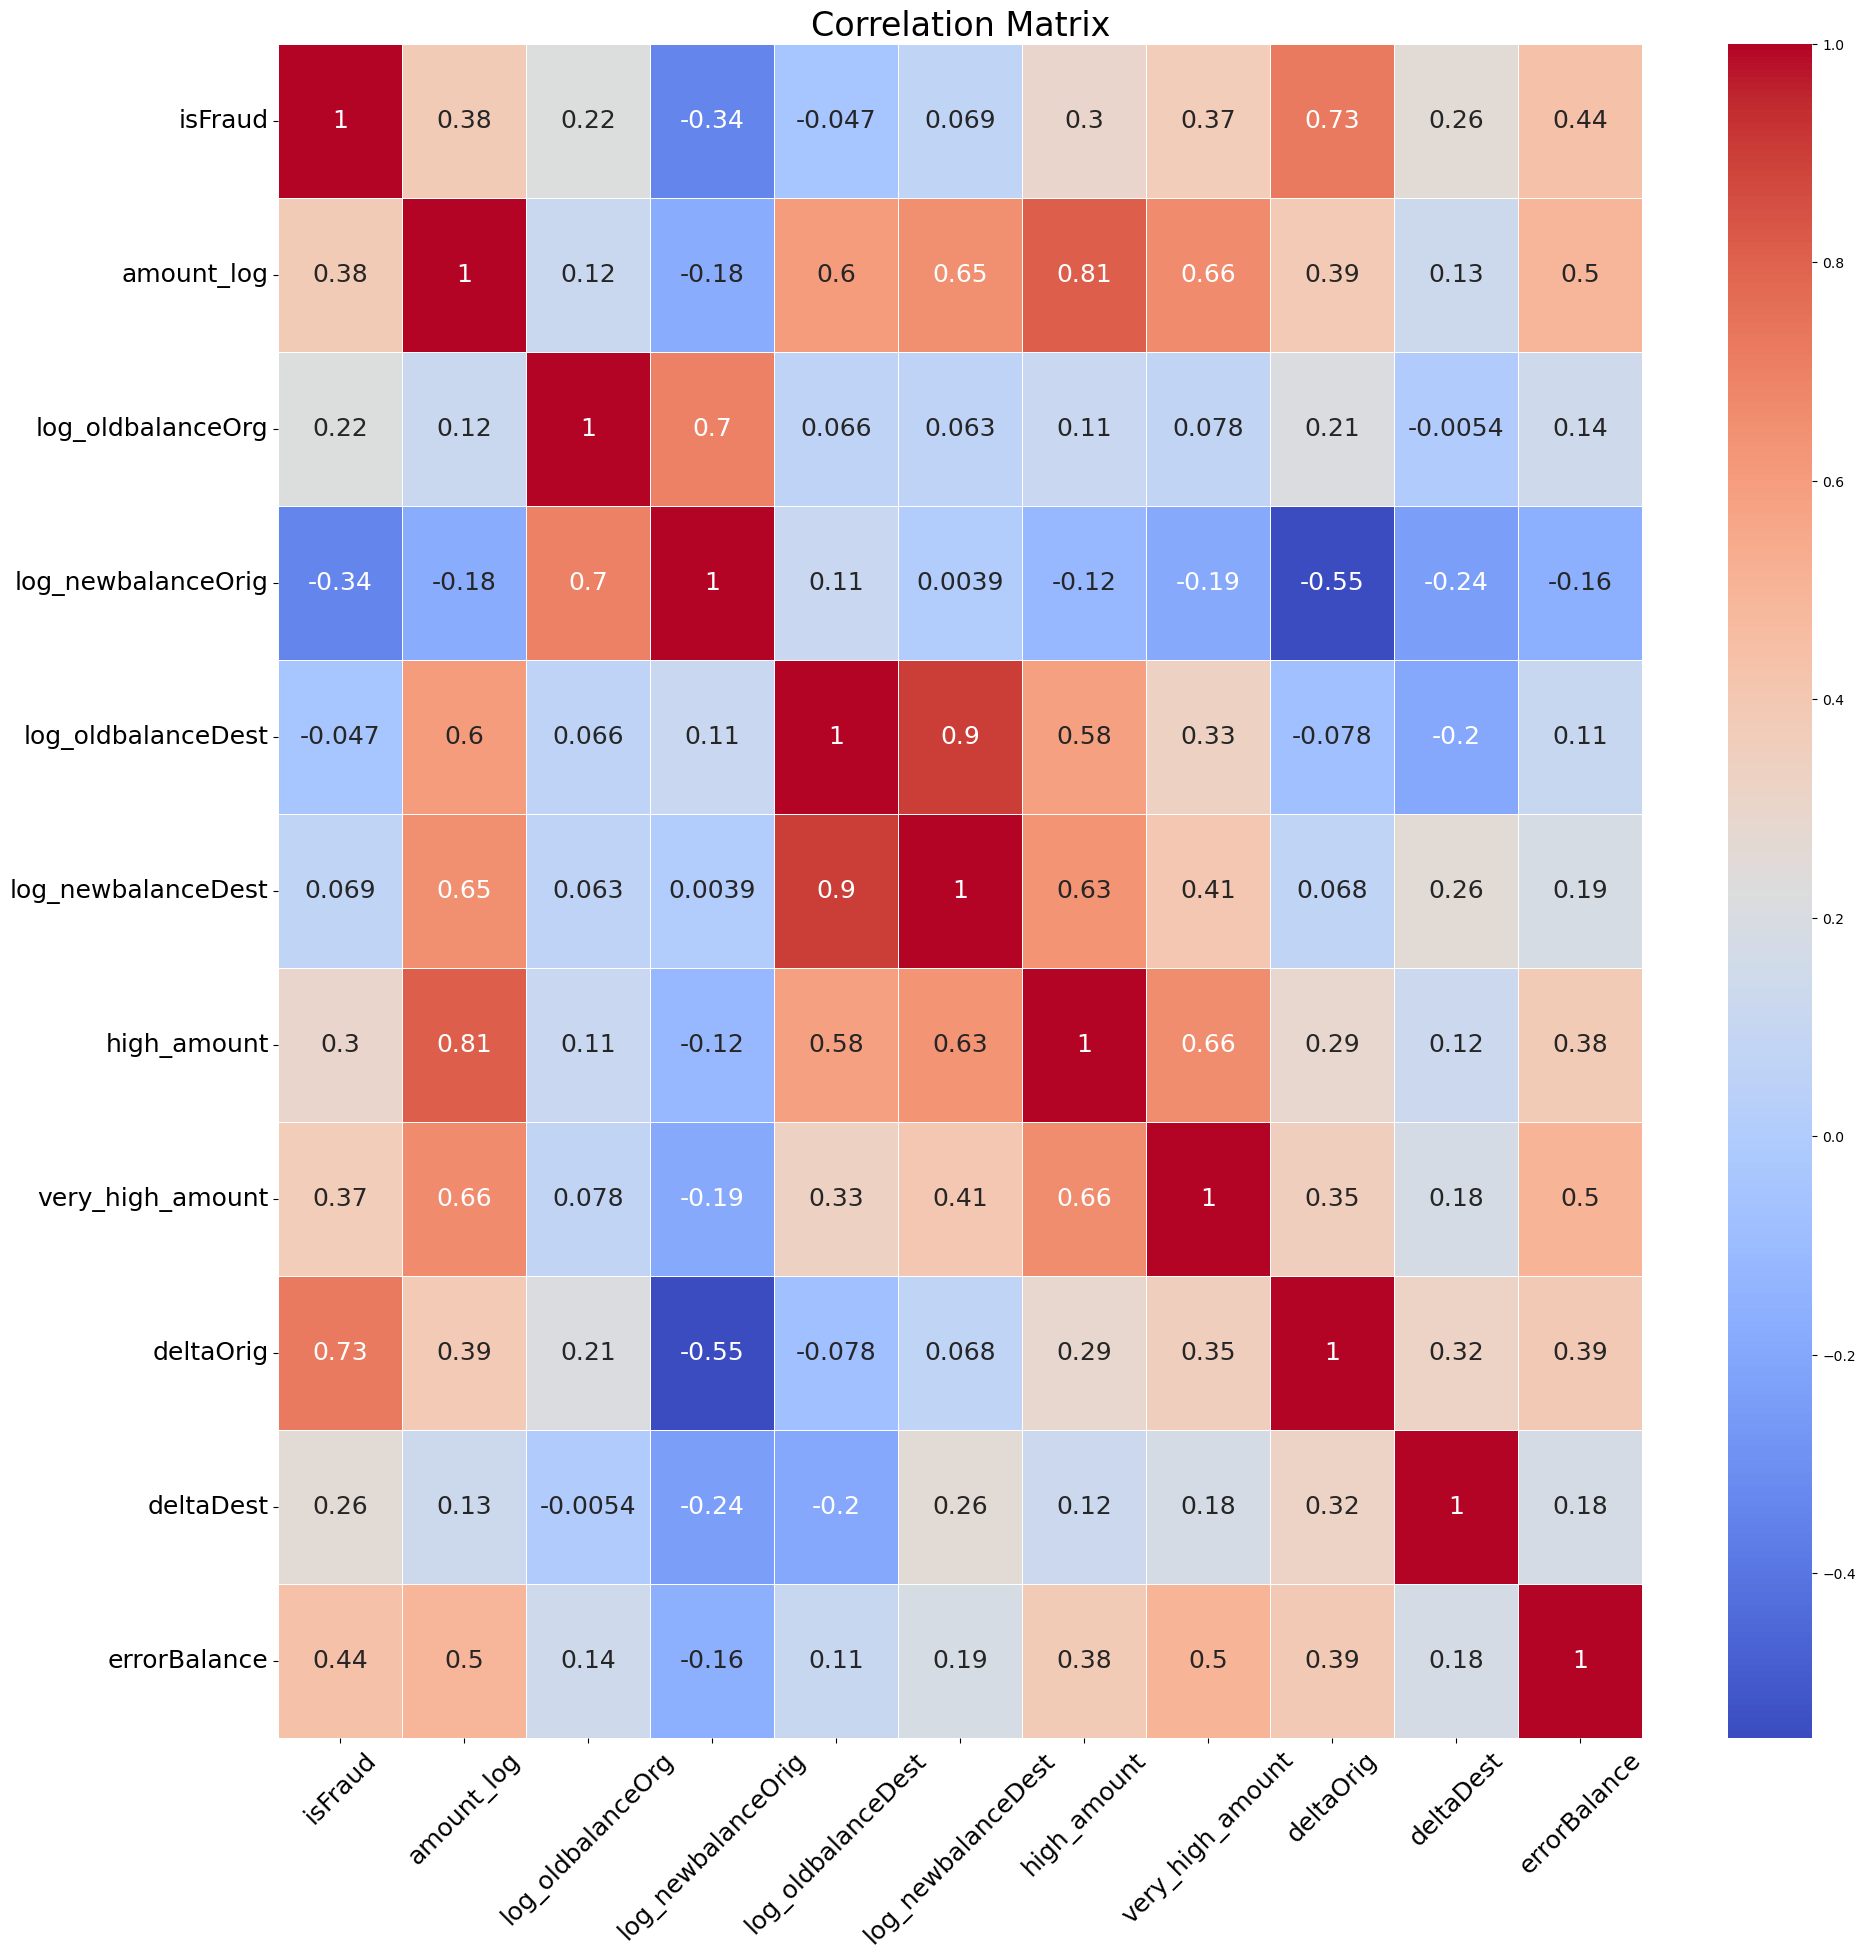

In [348]:
plt.figure(figsize=(22, 22))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 18},  # Increase number labels inside cells
    linewidths=0.5
)

plt.title('Correlation Matrix', fontsize=24)  # Increase title size

plt.xticks(fontsize=18, rotation=45)  # Increase x-axis label size
plt.yticks(fontsize=18, rotation=0)   # Increase y-axis label size

plt.show()
